### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [105]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [60]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.metrics import RootMeanSquaredError

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [5]:
microsoft = pd.read_csv('./data/MicrosoftStock.csv')

In [6]:
microsoft.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [7]:
microsoft.shape

(1259, 8)

In [8]:
microsoft.describe()

,index,open,high,low,close,volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,390827.000000,51.026394,51.436007,50.630397,51.063081,3.386946e+07
std,363.586303,14.859387,14.930144,14.774630,14.852117,1.958979e+07
min,390198.000000,27.350000,27.600000,27.230000,27.370000,7.425603e+06
25%,390512.500000,40.305000,40.637500,39.870000,40.310000,2.254879e+07
50%,390827.000000,47.440000,47.810000,47.005000,47.520000,2.938758e+07
75%,391141.500000,59.955000,60.435000,59.275000,59.730000,3.842024e+07
max,391456.000000,95.140000,96.070000,93.720000,95.010000,2.483542e+08


In [9]:
microsoft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB


### Step 3: Exploratory Data Analysis

In [10]:
microsoft['date'] = pd.to_datetime(microsoft['date'])

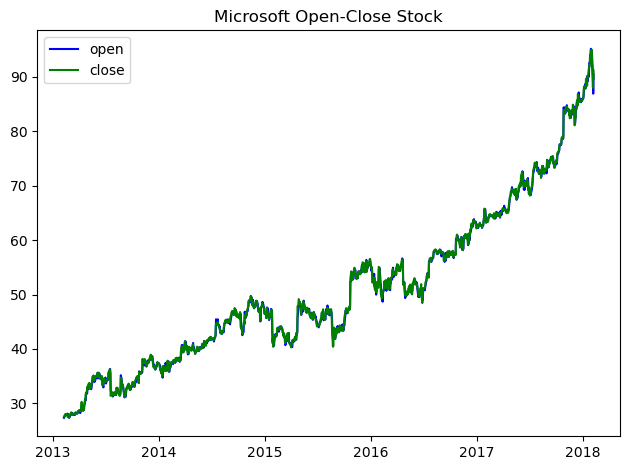

In [14]:
plt.plot(microsoft['date'], microsoft['open'], c='blue', label='open')
plt.plot(microsoft['date'], microsoft['close'], c='green', label='close')
plt.title('Microsoft Open-Close Stock')
plt.legend()
plt.tight_layout()

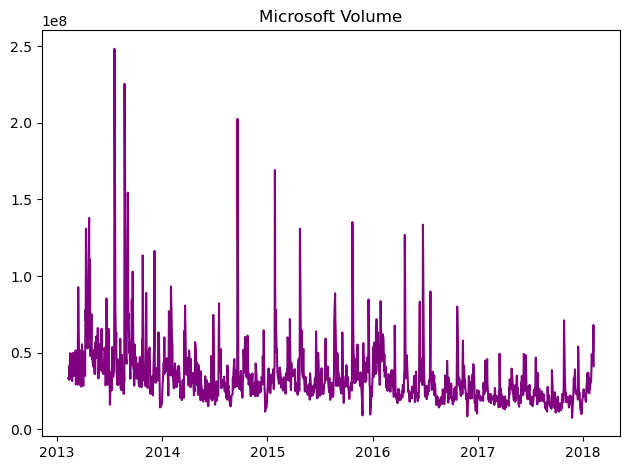

In [15]:
plt.plot(microsoft['date'], microsoft['volume'], c='purple')
plt.title('Microsoft Volume')
plt.tight_layout()

<Axes: >

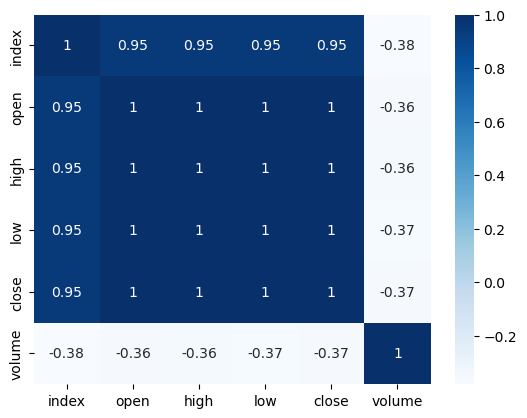

In [19]:
sns.heatmap(microsoft.select_dtypes(include=np.number).corr(), annot=True, cmap=plt.cm.Blues)

### Step 4: Preparing Data

In [26]:
dataset = microsoft.filter(['close']).values

In [33]:
training_num = int(np.ceil(len(dataset) * 0.95))

In [124]:
scaler = StandardScaler()

In [125]:
scaler_data = scaler.fit_transform(dataset)

In [126]:
train_data = scaler_data[:training_num, :]
test_data = scaler_data[training_num-60:, :]

In [127]:
X_train, y_train = list(), list()

In [128]:
for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [129]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [130]:
X_train = np.reshape(X_train, (*X_train.shape, 1))

In [131]:
X_test, y_test, y_test_real = list(), list(), list()

In [132]:
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])
    y_test_real.append(dataset[training_num+i-60, 0])

In [133]:
X_test, y_test = np.array(X_test), np.array(y_test)

In [134]:
X_test = np.reshape(X_test, (*X_test.shape, 1))

### Step 5: Feature Engineering

### Step 6: Model Development

In [98]:
class LSTMModel(keras.Model):
    def __init__(self):
        super().__init__(name='LSTMModel')
        self.lstm_1 = keras.layers.LSTM(64, return_sequences=True)
        self.lstm_2 = keras.layers.LSTM(64)
        self.dense = keras.layers.Dense(128)
        self.out = keras.layers.Dense(1)
        self.dropout = keras.layers.Dropout(0.5)

    def call(self, x, training=False):
        x = self.lstm_1(x)
        x = self.lstm_2(x)
        x = self.dense(x)
        x = self.dropout(x)
        x = self.out(x)
        return x

In [135]:
model = LSTMModel()

In [136]:
_ = model(tf.random.normal([1, 60, 1]))

In [137]:
model.summary()

Model: "LSTMModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                       │ (1, 60, 64)                 │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (1, 64)                     │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (1, 128)                    │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (1, 1)                      │             129 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,369 (228.00 KB)

 Trainable params: 58,369 (228.00 KB)

 Non-trainable params: 0 (0.00 B)

### Step 7: Model Compile and Fit

In [138]:
model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['RootMeanSquaredError']
)

In [140]:
history = model.fit(X_train, y_train, epochs=20)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - RootMeanSquaredError: 0.3119 - loss: 0.2097
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - RootMeanSquaredError: 0.1439 - loss: 0.1080
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - RootMeanSquaredError: 0.1283 - loss: 0.0957
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - RootMeanSquaredError: 0.1276 - loss: 0.0941
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - RootMeanSquaredError: 0.1282 - loss: 0.0946
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - RootMeanSquaredError: 0.1171 - loss: 0.0882
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - RootMeanSquaredError: 0.1180 - loss: 0.0875
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - RootMeanSquaredError: 0.1151 - loss: 0.0844
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - RootMeanSquaredError: 0.1198 - loss: 0.0860
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - RootMeanSquaredError: 0.1106 - loss: 0.0817
Epoch 11/20
36/36 ━━━━━━━━━━━

### Step 8: Model Evaluation

In [141]:
pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


In [147]:
pred = scaler.inverse_transform(pred)

In [148]:
mse = np.mean(((pred - y_test_real) ** 2))
rmse = np.sqrt(mse)

In [149]:
print("MSE", mse)
print("RMSE", np.sqrt(mse))

MSE 26.331317137829064
RMSE 5.131404986729177


In [150]:
train = microsoft[:training_num]
test = microsoft[training_num:]

In [151]:
test['predictions'] = pred

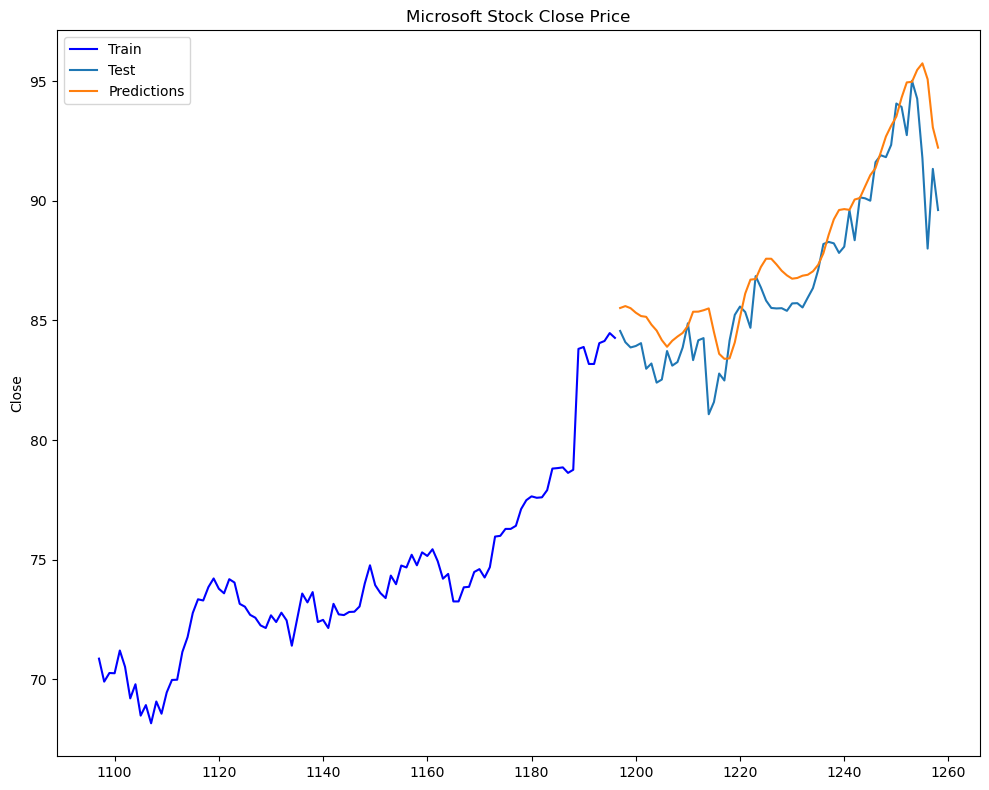

In [154]:
plt.figure(figsize=(10, 8))
plt.plot(train['close'][-100:], c="b")
plt.plot(test[['close', 'predictions']])
plt.title('Microsoft Stock Close Price')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])
plt.tight_layout()